# Supply Chain Risk Prediction: Data Understanding
This notebook covers the initial loading and exploratory data analysis (EDA) of the supply chain dataset to understand class balances, missing values, and data types.

In [7]:
# --- Setup & Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Load Raw Data
The dataset uses "latin-1" encoding. We load it and inspect the shape.

In [8]:
# --- Load Raw Data ---
# Dataset is saved in "latin-1" encoding.
df = pd.read_csv("../data/DataCoSupplyChainDataset.csv", encoding="latin-1")
print("Rows, Columns:", df.shape)
display(df.head())

Rows, Columns: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Basic Data Info
Checking column types and duplicate rows.

In [9]:
# --- Basic Data Info ---
df.info()
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

## Missing Values
Identifying columns with the highest number of null values.

In [10]:
# --- Missing Values ---
print("\nMissing values per column (worst 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))


Missing values per column (worst 15):
Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
dtype: int64


## Target Variable Analysis
Analyzing the distribution of the target variable `Late_delivery_risk`.

Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64


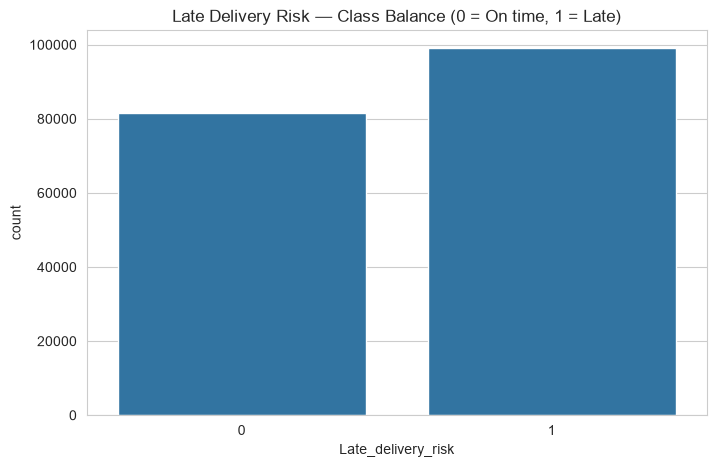

In [11]:
# --- Target Variable Analysis ---
print(df["Late_delivery_risk"].value_counts(normalize=True))

sns.countplot(x="Late_delivery_risk", data=df)
plt.title("Late Delivery Risk — Class Balance (0 = On time, 1 = Late)")
plt.show()

## Delivery Status Analysis
Visualizing the breakdown of actual delivery statuses.

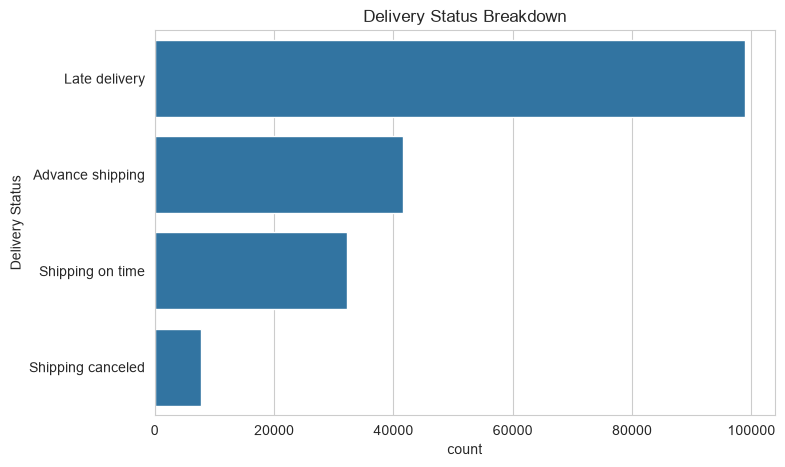

In [12]:
# --- Delivery Status Analysis ---
sns.countplot(y="Delivery Status", data=df, order=df["Delivery Status"].value_counts().index)
plt.title("Delivery Status Breakdown")
plt.show()